# Phase 05 — Net Win Contribution (NWC)

This notebook implements the approved baseline: for each recorded event, the striker receives the change in the batting side's selected win probability and the bowler receives its negative. It reads whichever candidate Phase 04 selected independently for each track. Primary rankings use only the untouched test split.

## Attribution contract

Within each innings, with selected batting-side probability W, the event contribution is:

\[
\Delta W_d = W_d-W_{d-1};\quad NWC^{bat}_d=\Delta W_d;\quad NWC^{bowl}_d=-\Delta W_d
\]

The prior for the first event is Phase 04's synthetic pre-innings state. There is no attribution across the innings break. The second-innings terminal state is anchored to the observed result; first-innings endpoints remain model probabilities. This is a transparent striker-bowler interaction metric: source data has no fielder identifiers, so wickets and extras are retained as audit flags rather than being reallocated.

In [1]:
from __future__ import annotations
import csv, gzip, json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = next(
    (
        x
        for x in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (x / "data" / "raw").exists()
    ),
    None,
)
assert PROJECT_ROOT is not None
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
METRICS_PATH = PROJECT_ROOT / "reports" / "metrics" / "phase_05_nwc_attribution.json"
P4_PATH = PROJECT_ROOT / "reports" / "metrics" / "phase_04_model_performance.json"
TRACKS = ["female_innings_1", "female_innings_2", "male_innings_1", "male_innings_2"]
P4 = json.loads(P4_PATH.read_text())
SELECTED_MODELS = {
    t: P4["tracks"][t]["selection"]["selected_model"] for t in TRACKS
}
assert set(SELECTED_MODELS.values()).issubset(
    {"naive_baseline", "logistic_regression", "random_forest"}
)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(f"Using Phase 04 selected probabilities: {SELECTED_MODELS}")


Using Phase 04 selected probabilities: {'female_innings_1': 'random_forest', 'female_innings_2': 'random_forest', 'male_innings_1': 'random_forest', 'male_innings_2': 'random_forest'}


## 1. Delivery-level NWC

Predictions are joined to source event rows using match_id, source_row and event_sequence. This preserves the raw authoritative event order and retains dismissal/extras fields for audit.

### 1.1 Build delivery-level NWC by model track

These helpers join each Phase 03 event table to its selected Phase 04 probability states. They retain delivery audit fields, create the pre-delivery probability, apply the terminal second-innings outcome rule, and verify that delivery changes telescope correctly.


In [2]:
KEYS = ["match_id", "event_sequence"]
AUDIT = [
    "match_id",
    "match_date",
    "gender",
    "match_innings",
    "batting_team",
    "bowling_team",
    "source_row",
    "event_sequence",
    "over",
    "ball",
    "striker",
    "non_striker",
    "bowler",
    "runs_batter",
    "runs_extras",
    "runs_total",
    "innings_score",
    "innings_wickets",
    "current_event_wicket",
    "player_out",
    "wicket_kind",
    "wides",
    "noballs",
    "byes",
    "legbyes",
    "penalty",
    "legal_delivery",
    "cumulative_innings_legal_balls",
    "batting_team_win_match",
]


def event_type(x):
    z = pd.Series("standard_delivery", index=x.index, dtype="string")
    z.loc[x.current_event_wicket.astype(bool)] = "dismissal"
    for col, label in [
        ("wides", "wide"),
        ("noballs", "no_ball"),
        ("byes", "byes"),
        ("legbyes", "legbyes"),
        ("penalty", "penalty"),
    ]:
        z.loc[x[col].fillna(0).gt(0)] = label
    return z


def make_track(t):
    src = pd.read_csv(
        INTERIM_DIR / f"phase_03_{t}.csv.gz", parse_dates=["match_date"], low_memory=False
    )
    pr = pd.read_csv(
        PROCESSED_DIR / f"phase_04_{t}_predictions.csv.gz",
        parse_dates=["match_date"],
        low_memory=False,
    )
    assert not src.duplicated(KEYS).any()
    assert pr.selected_model.eq(SELECTED_MODELS[t]).all()
    assert pr.groupby("match_id").is_pre_innings_state.sum().eq(1).all()
    st = pr.sort_values(["match_id", "state_sequence"], kind="stable").copy()
    st["win_probability_before"] = st.groupby(
        "match_id", sort=False
    ).win_probability_selected.shift()
    d = st[st.is_pre_innings_state.eq(0)].copy()
    assert d.win_probability_before.notna().all()
    assert d.groupby("match_id").state_sequence.min().eq(1).all()
    assert d.groupby("match_id").state_sequence.diff().dropna().eq(1).all()
    source_events = (
        src[AUDIT].sort_values(["match_id", "event_sequence"], kind="stable").reset_index(drop=True)
    )
    d = d.sort_values(["match_id", "event_sequence"], kind="stable").reset_index(drop=True)
    assert len(d) == len(source_events)
    assert d[KEYS].astype(str).equals(source_events[KEYS].astype(str))
    for x in AUDIT:
        if x in KEYS:
            continue
        if x not in d.columns:
            d[x] = source_events[x].to_numpy()
    d["track"] = t
    d["event_type"] = event_type(d)
    # Only the end of innings two is also the end of the match. Make that
    # terminal post-event state equal to the observed binary outcome.
    if int(d["match_innings"].iloc[0]) == 2:
        terminal = d["event_sequence"].eq(d.groupby("match_id")["event_sequence"].transform("max"))
        d.loc[terminal, "win_probability_selected"] = d.loc[
            terminal, "batting_team_win_match"
        ].astype(float)
    d["win_probability_change"] = d.win_probability_selected - d.win_probability_before
    d["batting_nwc"] = d.win_probability_change
    d["bowling_nwc"] = -d.win_probability_change
    d["nwc_pair_sum"] = d.batting_nwc + d.bowling_nwc
    assert (
        np.isfinite(
            d[["win_probability_before", "win_probability_selected", "win_probability_change"]]
        )
        .all()
        .all()
    )
    assert np.allclose(d.nwc_pair_sum, 0, atol=1e-12)
    ep = (
        st.groupby("match_id", sort=False)
        .agg(
            split=("split", "first"),
            gender=("gender", "first"),
            match_innings=("match_innings", "first"),
            start_probability=("win_probability_selected", "first"),
        )
        .reset_index()
    )
    end_probability = d.groupby("match_id", sort=False)["win_probability_selected"].last()
    delta_sum = d.groupby("match_id", sort=False)["win_probability_change"].sum()
    ep["end_probability"] = ep["match_id"].map(end_probability)
    ep["summed_delivery_change"] = ep["match_id"].map(delta_sum)
    ep["telescoping_difference"] = ep.summed_delivery_change - (
        ep.end_probability - ep.start_probability
    )
    assert np.allclose(ep.telescoping_difference, 0, atol=1e-12)
    return d, ep


### 1.2 Combine the four tracks

Run the same calculation for each gender-and-innings model track, concatenate the delivery records, and retain one compact preview for auditing.


In [3]:
parts = []
eps = []
for t in TRACKS:
    d, e = make_track(t)
    parts.append(d)
    eps.append(e.assign(track=t))
delivery_nwc = pd.concat(parts, ignore_index=True)
innings_endpoints = pd.concat(eps, ignore_index=True)
assert not delivery_nwc.duplicated(["track", *KEYS]).any()
assert len(delivery_nwc) == sum(P4["tracks"][t]["source_delivery_rows"] for t in TRACKS)
display(
    delivery_nwc[
        [
            "track",
            "match_id",
            "event_sequence",
            "striker",
            "bowler",
            "win_probability_before",
            "win_probability_selected",
            "win_probability_change",
            "event_type",
        ]
    ].head()
)


,track,match_id,event_sequence,striker,bowler,win_probability_before,win_probability_selected,win_probability_change,event_type
0,female_innings_1,355988,1,LR Doolan,J Goswami,0.546453,0.198203,-0.348249,standard_delivery
1,female_innings_1,355988,2,LR Doolan,J Goswami,0.198203,0.358369,0.160166,standard_delivery
2,female_innings_1,355988,3,SW Bates,J Goswami,0.358369,0.581110,0.222740,standard_delivery
3,female_innings_1,355988,4,SW Bates,J Goswami,0.581110,0.535500,-0.045610,standard_delivery
4,female_innings_1,355988,5,SW Bates,J Goswami,0.535500,0.428686,-0.106814,standard_delivery


## 2. Player-level aggregation and reconciliation

Each delivery creates one batting and one bowling record. The checks establish exact delivery pair, player-match, and innings telescoping reconciliation.

### 2.1 Create player-event records

Each delivery creates one batting record for the striker and one bowling record for the bowler. Their contributions are equal in magnitude and opposite in sign.


In [4]:
bat = delivery_nwc[
    [
        "match_id",
        "match_date",
        "gender",
        "split",
        "track",
        "match_innings",
        "batting_team",
        "striker",
        "batting_nwc",
    ]
].rename(columns={"batting_team": "team", "striker": "player", "batting_nwc": "nwc"})
bat["role"] = "batting"
bowl = delivery_nwc[
    [
        "match_id",
        "match_date",
        "gender",
        "split",
        "track",
        "match_innings",
        "bowling_team",
        "bowler",
        "bowling_nwc",
    ]
].rename(columns={"bowling_team": "team", "bowler": "player", "bowling_nwc": "nwc"})
bowl["role"] = "bowling"
player_events = pd.concat([bat, bowl], ignore_index=True)
assert np.allclose(player_events.groupby(["track", "match_id"]).nwc.sum(), 0, atol=1e-12)


### 2.2 Aggregate player NWC and run reconciliation checks

This cell creates player-match and player-split summaries, then verifies zero-sum delivery, match, innings, and dataset totals before showing audit tables.


In [5]:
long = player_events.groupby(
    ["match_id", "match_date", "gender", "split", "team", "player", "role"], as_index=False
).agg(nwc=("nwc", "sum"), delivery_events=("nwc", "size"))
wide = long.pivot_table(
    index=["match_id", "match_date", "gender", "split", "team", "player"],
    columns="role",
    values=["nwc", "delivery_events"],
    aggfunc="sum",
    fill_value=0,
).sort_index(axis=1)
wide.columns = [
    {
        "delivery_events_batting": "batting_delivery_events",
        "delivery_events_bowling": "bowling_delivery_events",
        "nwc_batting": "batting_nwc",
        "nwc_bowling": "bowling_nwc",
    }[a + "_" + b]
    for a, b in wide.columns
]
player_match = wide.reset_index()
for x in ["batting_nwc", "bowling_nwc", "batting_delivery_events", "bowling_delivery_events"]:
    if x not in player_match:
        player_match[x] = 0.0
player_match["total_nwc"] = player_match.batting_nwc + player_match.bowling_nwc
player_match["season_year"] = player_match.match_date.dt.year.astype("int64")
summary = (
    player_match.groupby(["gender", "split", "team", "player"], as_index=False)
    .agg(
        matches=("match_id", "nunique"),
        batting_delivery_events=("batting_delivery_events", "sum"),
        bowling_delivery_events=("bowling_delivery_events", "sum"),
        batting_nwc=("batting_nwc", "sum"),
        bowling_nwc=("bowling_nwc", "sum"),
        total_nwc=("total_nwc", "sum"),
    )
    .sort_values(["split", "total_nwc"], ascending=[True, False], kind="stable")
)
test_summary = summary[summary.split.eq("test")].copy()
pair_error = float(delivery_nwc.nwc_pair_sum.abs().max())
match_error = float(
    player_match.groupby(["gender", "split", "match_id"]).total_nwc.sum().abs().max()
)
innings_error = float(innings_endpoints.telescoping_difference.abs().max())
dataset_total = float(player_events.nwc.sum())
assert (
    pair_error <= 1e-12
    and match_error <= 1e-12
    and innings_error <= 1e-12
    and abs(dataset_total) <= 1e-10
)
event_audit = (
    delivery_nwc.groupby(["event_type", "wicket_kind"], dropna=False, as_index=False)
    .agg(
        delivery_events=("match_id", "size"),
        mean_absolute_probability_change=("win_probability_change", lambda x: x.abs().mean()),
        net_probability_change=("win_probability_change", "sum"),
    )
    .sort_values("delivery_events", ascending=False, kind="stable")
)
display(
    pd.DataFrame(
        [
            {"check": "max delivery pair sum", "value": pair_error},
            {"check": "max match player total", "value": match_error},
            {"check": "max innings telescoping difference", "value": innings_error},
            {"check": "dataset player-event total", "value": dataset_total},
        ]
    )
)
display(event_audit.head(20))
display(test_summary.head(15))


,check,value
0,max delivery pair sum,0.000000e+00
1,max match player total,3.608225e-16
2,max innings telescoping difference,2.220446e-16
3,dataset player-event total,1.709743e-14


,event_type,wicket_kind,delivery_events,mean_absolute_probability_change,net_probability_change
16,standard_delivery,NaN,1014275,0.013957,631.928148
20,wide,NaN,52600,0.015365,588.052148
3,dismissal,caught,32170,0.027500,-798.708753
2,dismissal,bowled,14935,0.025134,-336.604795
12,legbyes,NaN,13757,0.010044,22.448897
14,no_ball,NaN,6499,0.021090,113.587706
9,dismissal,run out,6347,0.023750,-122.457837
7,dismissal,lbw,5526,0.026971,-134.483555
1,byes,NaN,5344,0.013558,35.977163
10,dismissal,stumped,2237,0.024196,-48.712327


,gender,split,team,player,matches,batting_delivery_events,bowling_delivery_events,batting_nwc,bowling_nwc,total_nwc
4223,male,test,Austria,Karanbir Singh,25,611,165,3.606778,-0.314160,3.292617
781,female,test,South Africa,L Wolvaardt,17,475,0,3.103324,0.000000,3.103324
791,female,test,Sri Lanka,AC Jayangani,17,397,293,2.539849,0.561038,3.100886
170,female,test,Cyprus,I Chathurani,7,256,165,1.765083,1.144703,2.909786
67,female,test,Bhutan,N Choden,8,269,0,2.384197,0.000000,2.384197
4556,male,test,Denmark,HAM Shah,9,342,105,2.244223,0.019823,2.264046
334,female,test,India,Shafali Verma,20,444,143,1.390358,0.622411,2.012769
4903,male,test,Japan,C Hinze,12,46,255,0.039096,1.934400,1.973496
5388,male,test,Romania,V Saini,14,330,229,1.550980,0.379056,1.930037
5650,male,test,Sweden,Zabiullah Zahid,17,52,392,1.046876,0.620430,1.667306


## 3. Matchup win-probability line and separate player NWC

The chart names both teams and keeps one fixed-team probability perspective over the full match. The 50% line separates the two teams: the upper region is lightly shaded in the reference team's colour, while the lower region is lightly shaded in the opponent's colour. Line segments above and below 50% adopt the corresponding team colour, making the currently favoured side immediately visible. The innings boundary remains unconnected because it is not a delivery-level attribution event. Player involvement is marked on the probability chart, while player NWC is shown separately.


### 3.1 Select a test match and player

Set `REPRESENTATIVE_MATCH_ID` and `PLAYER_OF_INTEREST` to reproduce a specific test-match example. If the match ID is `None`, the notebook selects the test match with the largest in-play reference-team probability range; if the player is `None`, it selects the player with the largest absolute match NWC.


In [6]:
# Use the previously discussed New Zealand vs England test-match example.
# Set either value to None to return to automatic example selection.
REPRESENTATIVE_MATCH_ID = 1496546
PLAYER_OF_INTEREST = "NH Patel"

test_deliveries = delivery_nwc.loc[delivery_nwc["split"].eq("test")].copy()
first_events = (
    test_deliveries.sort_values(["match_id", "match_innings", "event_sequence"], kind="stable")
    .groupby("match_id", as_index=False, sort=False)
    .head(1)[["match_id", "batting_team"]]
    .rename(columns={"batting_team": "reference_team"})
)
match_plot = test_deliveries.merge(first_events, on="match_id", how="inner", validate="many_to_one")
match_plot["reference_team_win_probability"] = np.where(
    match_plot["batting_team"].eq(match_plot["reference_team"]),
    match_plot["win_probability_selected"],
    1 - match_plot["win_probability_selected"],
)
# Select on in-play movement only: terminal outcome forcing is essential for NWC,
# but would otherwise make the automatic case choice depend mainly on the last ball.
terminal_second = match_plot["match_innings"].eq(2) & match_plot["event_sequence"].eq(
    match_plot.groupby("match_id")["event_sequence"].transform("max")
)
match_ranges = (
    match_plot.loc[~terminal_second]
    .groupby("match_id")["reference_team_win_probability"]
    .agg(lambda values: values.max() - values.min())
)
if REPRESENTATIVE_MATCH_ID is None:
    representative_match_id = match_ranges.idxmax()
else:
    representative_match_id = REPRESENTATIVE_MATCH_ID
    if representative_match_id not in set(match_plot["match_id"]):
        raise ValueError(
            f"Match {representative_match_id} is not available in the untouched test split."
        )
representative = match_plot.loc[match_plot["match_id"].eq(representative_match_id)].copy()
reference_team = representative["reference_team"].iloc[0]
representative = representative.sort_values(["match_innings", "event_sequence"], kind="stable")
innings_one_team = representative.loc[representative["match_innings"].eq(1), "batting_team"].iloc[0]
innings_two_team = representative.loc[representative["match_innings"].eq(2), "batting_team"].iloc[0]
opponent_team = innings_two_team if reference_team == innings_one_team else innings_one_team
match_date = pd.Timestamp(representative["match_date"].iloc[0]).date().isoformat()

match_players = player_match.loc[player_match["match_id"].eq(representative_match_id)].copy()
if PLAYER_OF_INTEREST is None:
    player_of_interest = match_players.loc[match_players["total_nwc"].abs().idxmax(), "player"]
else:
    player_of_interest = PLAYER_OF_INTEREST
    if player_of_interest not in set(match_players["player"]):
        raise ValueError(
            f"{player_of_interest!r} did not participate in representative match "
            f"{representative_match_id}."
        )
player_team = match_players.loc[match_players["player"].eq(player_of_interest), "team"].iloc[0]


### 3.2 Prepare plotting coordinates and player contribution data

This cell fixes one team as the win-probability reference, creates a two-innings legal-delivery x-axis, identifies deliveries where the player batted or bowled.


In [7]:
representative["legal_ball_in_innings"] = representative["cumulative_innings_legal_balls"].clip(
    lower=1, upper=120
)
representative["match_legal_ball_x"] = np.where(
    representative["match_innings"].eq(1),
    representative["legal_ball_in_innings"],
    120 + representative["legal_ball_in_innings"],
)
representative["player_role"] = np.select(
    [
        representative["striker"].eq(player_of_interest),
        representative["bowler"].eq(player_of_interest),
    ],
    ["batting", "bowling"],
    default="not_involved",
)
representative["player_delivery_nwc"] = np.select(
    [representative["player_role"].eq("batting"), representative["player_role"].eq("bowling")],
    [representative["batting_nwc"], representative["bowling_nwc"]],
    default=0.0,
)
player_events = representative.loc[representative["player_role"].ne("not_involved")].copy()
player_batting_nwc = float(
    player_events.loc[player_events["player_role"].eq("batting"), "player_delivery_nwc"].sum()
)
player_bowling_nwc = float(
    player_events.loc[player_events["player_role"].eq("bowling"), "player_delivery_nwc"].sum()
)
player_total_nwc = player_batting_nwc + player_bowling_nwc

innings_one = representative.loc[representative["match_innings"].eq(1)]
innings_two = representative.loc[representative["match_innings"].eq(2)]
ticks = [1, 30, 60, 90, 120, 150, 180, 210, 240]
tick_labels = ["1", "30", "60", "90", "120", "30", "60", "90", "120"]
innings_break_x = 120
reference_colour, opponent_colour = "#2675C9", "#2E8B57"


### 3.3 Plot the match win probability

The chart shows one fixed reference team's predicted win probability across both innings. Actual delivery-to-delivery paths are solid and change colour at 50%. A grey dotted segment connects the two innings to show a model transition with no intervening delivery; it remains excluded from player NWC. The bottom legend names both teams explicitly.


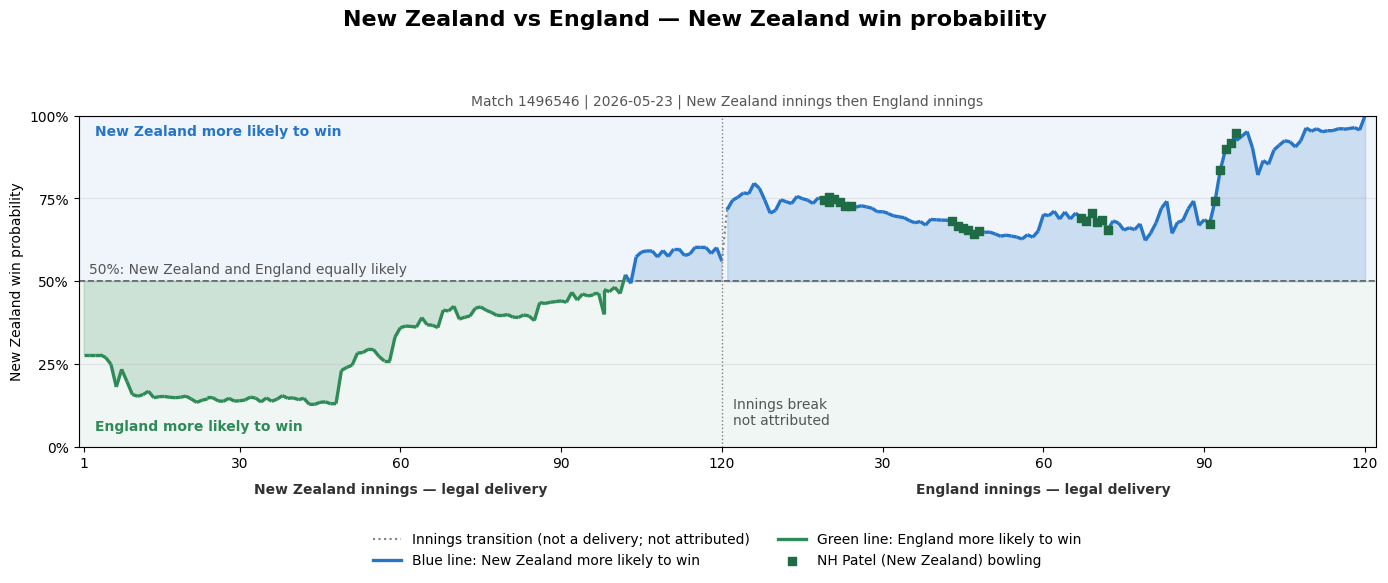

In [8]:
# Figure 1: one continuous fixed-team probability path, colour-coded around 50%.
from matplotlib.collections import LineCollection

fig, ax_wp = plt.subplots(figsize=(14, 6.2))
ax_wp.axhspan(0.5, 1.0, color=reference_colour, alpha=0.07, zorder=0)
ax_wp.axhspan(0.0, 0.5, color=opponent_colour, alpha=0.07, zorder=0)

for frame in [innings_one, innings_two]:
    x = frame["match_legal_ball_x"].to_numpy(dtype=float)
    y = frame["reference_team_win_probability"].to_numpy(dtype=float)
    points = np.column_stack([x, y])
    segments = np.stack([points[:-1], points[1:]], axis=1)
    segment_midpoints = (y[:-1] + y[1:]) / 2
    segment_colours = np.where(
        segment_midpoints >= 0.5,
        reference_colour,
        opponent_colour,
    )
    ax_wp.add_collection(
        LineCollection(
            segments,
            colors=segment_colours,
            linewidths=2.4,
            zorder=2,
        )
    )
    ax_wp.fill_between(
        x,
        y,
        0.5,
        where=y >= 0.5,
        color=reference_colour,
        alpha=0.18,
        interpolate=True,
        zorder=1,
    )
    ax_wp.fill_between(
        x,
        y,
        0.5,
        where=y <= 0.5,
        color=opponent_colour,
        alpha=0.18,
        interpolate=True,
        zorder=1,
    )

# The dotted connector is a model transition, not an observed delivery.
ax_wp.plot(
    [innings_one["match_legal_ball_x"].iloc[-1], innings_two["match_legal_ball_x"].iloc[0]],
    [
        innings_one["reference_team_win_probability"].iloc[-1],
        innings_two["reference_team_win_probability"].iloc[0],
    ],
    color="#7F7F7F",
    linestyle=":",
    linewidth=1.5,
    zorder=2,
    label="Innings transition (not a delivery; not attributed)",
)

# Empty handles make the two line meanings explicit in the bottom legend.
ax_wp.plot(
    [],
    [],
    color=reference_colour,
    linewidth=2.4,
    label=f"Blue line: {reference_team} more likely to win",
)
ax_wp.plot(
    [],
    [],
    color=opponent_colour,
    linewidth=2.4,
    label=f"Green line: {opponent_team} more likely to win",
)
for role, colour, marker, label in [
    ("batting", "#3D8DFF", "o", f"{player_of_interest} ({player_team}) batting"),
    ("bowling", "#1E6B46", "s", f"{player_of_interest} ({player_team}) bowling"),
]:
    events = player_events.loc[player_events["player_role"].eq(role)]
    if not events.empty:
        ax_wp.scatter(
            events["match_legal_ball_x"],
            events["reference_team_win_probability"],
            color=colour,
            marker=marker,
            s=34,
            zorder=4,
            label=label,
        )
ax_wp.axhline(0.5, color="#555555", linestyle="--", linewidth=1.2, zorder=1)
ax_wp.text(
    2,
    0.515,
    f"50%: {reference_team} and {opponent_team} equally likely",
    color="#555555",
    fontsize=10,
    va="bottom",
)
ax_wp.text(
    3, 0.94, f"{reference_team} more likely to win", color=reference_colour, fontweight="bold"
)
ax_wp.text(3, 0.05, f"{opponent_team} more likely to win", color=opponent_colour, fontweight="bold")
ax_wp.axvline(innings_break_x, color="#7F7F7F", linestyle=":", linewidth=1)
ax_wp.text(
    innings_break_x + 2,
    0.06,
    "Innings break\nnot attributed",
    color="#555555",
    fontsize=10,
    va="bottom",
)
ax_wp.set_xlim(0, 242)
ax_wp.set_ylim(0, 1)
ax_wp.set_yticks([0, 0.25, 0.5, 0.75, 1])
ax_wp.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
ax_wp.set_xticks(ticks, tick_labels)
ax_wp.set_ylabel(f"{reference_team} win probability")
fig.suptitle(
    f"{reference_team} vs {opponent_team} — {reference_team} win probability",
    fontsize=16,
    fontweight="bold",
    y=0.985,
)
ax_wp.set_title(
    f"Match {representative_match_id} | {match_date} | "
    f"{innings_one_team} innings then {innings_two_team} innings",
    fontsize=10,
    color="#555555",
    pad=8,
)
ax_wp.text(
    60,
    -0.14,
    f"{innings_one_team} innings — legal delivery",
    transform=ax_wp.get_xaxis_transform(),
    ha="center",
    color="#333333",
    fontweight="bold",
)
ax_wp.text(
    180,
    -0.14,
    f"{innings_two_team} innings — legal delivery",
    transform=ax_wp.get_xaxis_transform(),
    ha="center",
    color="#333333",
    fontweight="bold",
)
ax_wp.grid(axis="y", alpha=0.25)
if not player_events.empty:
    ax_wp.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=2,
        frameon=False,
    )
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


### 3.4 Plot the player's delivery-level NWC

The figure always keeps one panel for each innings, even when the player has no attributed striker or bowler events in one of them. Both panels share one symmetric y-axis centred on zero, so bar heights are directly comparable. Events sharing one legal-delivery position, such as wides or no-balls, are summed before plotting so bars do not overlap.


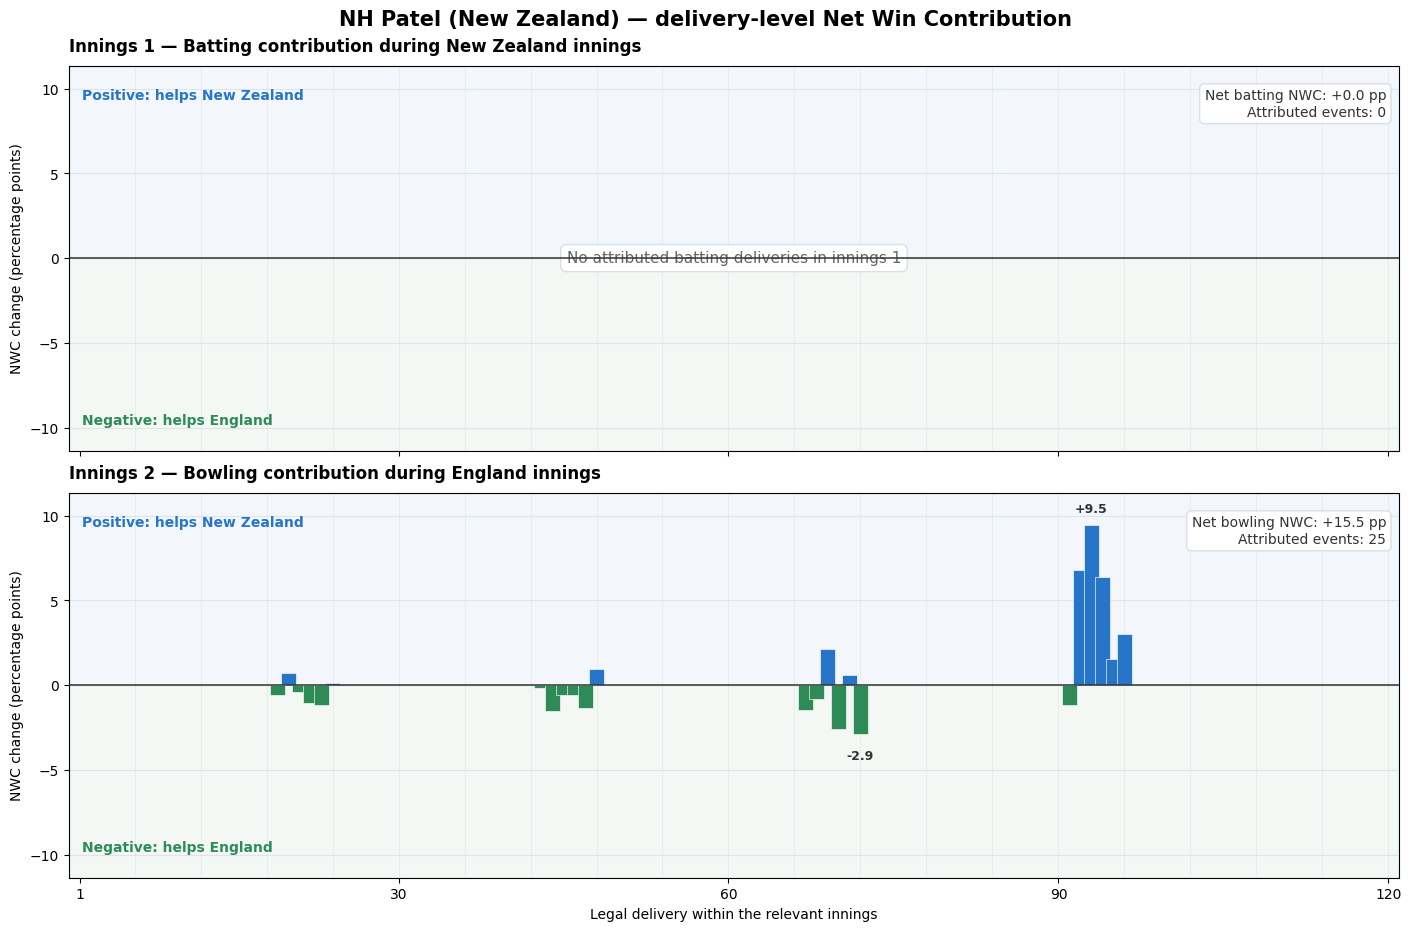

Representative test match: New Zealand vs England (1496546); player: NH Patel (New Zealand); batting NWC: +0.000; bowling NWC: +0.155; total NWC: +0.155


In [9]:
# Figure 2: keep a stable two-innings layout for every selected player.
player_colour = reference_colour if player_team == reference_team else opponent_colour
other_team = opponent_team if player_team == reference_team else reference_team
other_colour = opponent_colour if player_team == reference_team else reference_colour

panel_data = {}
for innings_number in [1, 2]:
    innings_team = innings_one_team if innings_number == 1 else innings_two_team
    role = "batting" if player_team == innings_team else "bowling"
    events = player_events.loc[
        player_events["match_innings"].eq(innings_number)
        & player_events["player_role"].eq(role)
    ].copy()
    # Illegal deliveries can share a legal-ball position, so sum them before plotting.
    delivery_bars = (
        events.groupby("legal_ball_in_innings", as_index=False)
        .agg(
            nwc=("player_delivery_nwc", "sum"),
            attributed_events=("player_delivery_nwc", "size"),
        )
        .sort_values("legal_ball_in_innings", kind="stable")
    )
    delivery_bars["nwc_pp"] = delivery_bars["nwc"] * 100
    assert np.isclose(
        delivery_bars["nwc"].sum(),
        events["player_delivery_nwc"].sum(),
        atol=1e-12,
    )

    panel_data[innings_number] = {
        "innings_team": innings_team,
        "role": role,
        "events": events,
        "delivery_bars": delivery_bars,
    }

maximum_absolute_nwc_pp = max(
    (
        float(panel["delivery_bars"]["nwc_pp"].abs().max())
        for panel in panel_data.values()
        if not panel["delivery_bars"].empty
    ),
    default=0.0,
)
shared_limit = max(5.0, maximum_absolute_nwc_pp * 1.20)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9.2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for ax, innings_number in zip(axes, [1, 2], strict=True):
    panel = panel_data[innings_number]
    role = panel["role"]
    events = panel["events"]
    delivery_bars = panel["delivery_bars"]
    role_innings_team = panel["innings_team"]

    values_pp = delivery_bars["nwc_pp"]
    bar_colours = np.where(values_pp.ge(0), player_colour, other_colour)

    ax.axhspan(0, shared_limit, color=player_colour, alpha=0.055, zorder=0)
    ax.axhspan(-shared_limit, 0, color=other_colour, alpha=0.055, zorder=0)
    for over_boundary in range(6, 121, 6):
        ax.axvline(over_boundary, color="#D9DEE7", linewidth=0.6, alpha=0.55, zorder=0)

    ax.bar(
        delivery_bars["legal_ball_in_innings"],
        values_pp,
        color=bar_colours,
        width=1.45,
        edgecolor="white",
        linewidth=0.45,
        zorder=3,
    )
    ax.axhline(0, color="#333333", linewidth=1.1, zorder=4)
    ax.set_ylim(-shared_limit, shared_limit)
    ax.set_xlim(0, 121)
    ax.set_ylabel("NWC change (percentage points)")
    ax.set_title(
        f"Innings {innings_number} — {role.title()} contribution during "
        f"{role_innings_team} innings",
        loc="left",
        fontsize=12,
        fontweight="bold",
        pad=10,
    )
    ax.text(
        0.01,
        0.94,
        f"Positive: helps {player_team}",
        transform=ax.transAxes,
        color=player_colour,
        fontweight="bold",
        va="top",
    )
    ax.text(
        0.01,
        0.06,
        f"Negative: helps {other_team}",
        transform=ax.transAxes,
        color=other_colour,
        fontweight="bold",
        va="bottom",
    )
    ax.text(
        0.99,
        0.94,
        f"Net {role} NWC: {values_pp.sum():+.1f} pp\n"
        f"Attributed events: {len(events)}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        color="#333333",
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#D9DEE7"},
    )

    if delivery_bars.empty:
        ax.text(
            0.5,
            0.5,
            f"No attributed {role} deliveries in innings {innings_number}",
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=11,
            color="#666666",
            bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "#D9DEE7"},
        )
    else:
        # Label the largest positive and negative swings without crowding every bar.
        extreme_rows = [delivery_bars.loc[values_pp.idxmax()]]
        if values_pp.min() < 0:
            extreme_rows.append(delivery_bars.loc[values_pp.idxmin()])
        for row in extreme_rows:
            value = row["nwc_pp"]
            ax.annotate(
                f"{value:+.1f}",
                (row["legal_ball_in_innings"], value),
                xytext=(0, 7 if value >= 0 else -11),
                textcoords="offset points",
                ha="center",
                va="bottom" if value >= 0 else "top",
                fontsize=9,
                fontweight="bold",
                color="#333333",
            )

    ax.grid(axis="y", color="#D9DEE7", linewidth=0.8, alpha=0.75)
    ax.set_axisbelow(True)

axes[-1].set_xticks([1, 30, 60, 90, 120])
axes[-1].set_xlabel("Legal delivery within the relevant innings")
fig.suptitle(
    f"{player_of_interest} ({player_team}) — delivery-level Net Win Contribution",
    fontsize=15,
    fontweight="bold",
)
plt.show()

print(
    f"Representative test match: {reference_team} vs {opponent_team} "
    f"({representative_match_id}); player: {player_of_interest} ({player_team}); "
    f"batting NWC: {player_batting_nwc:+.3f}; "
    f"bowling NWC: {player_bowling_nwc:+.3f}; total NWC: {player_total_nwc:+.3f}"
)


## 4. Untouched-test player NWC

Positive NWC means the player improved their own team's estimated win probability over events where they were striker or bowler. This is descriptive—not a talent estimate independent of opportunity, opponent, or unobserved fielding.

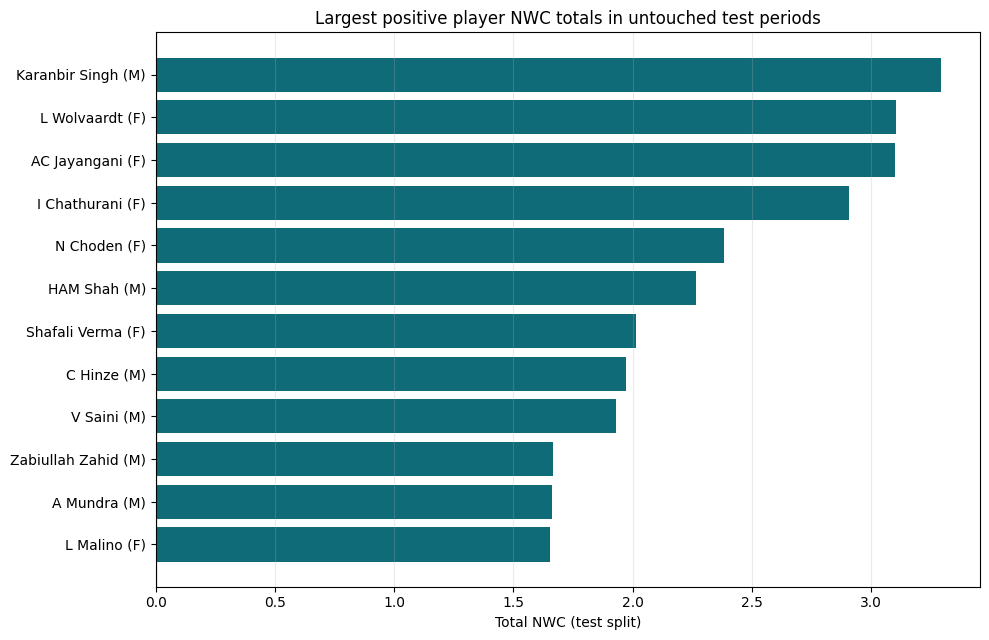

,gender,team,player,matches,batting_nwc,bowling_nwc,total_nwc
4223,male,Austria,Karanbir Singh,25,3.606778,-0.314160,3.292617
781,female,South Africa,L Wolvaardt,17,3.103324,0.000000,3.103324
791,female,Sri Lanka,AC Jayangani,17,2.539849,0.561038,3.100886
170,female,Cyprus,I Chathurani,7,1.765083,1.144703,2.909786
67,female,Bhutan,N Choden,8,2.384197,0.000000,2.384197
4556,male,Denmark,HAM Shah,9,2.244223,0.019823,2.264046
334,female,India,Shafali Verma,20,1.390358,0.622411,2.012769
4903,male,Japan,C Hinze,12,0.039096,1.934400,1.973496
5388,male,Romania,V Saini,14,1.550980,0.379056,1.930037
5650,male,Sweden,Zabiullah Zahid,17,1.046876,0.620430,1.667306


In [10]:
plot = (
    test_summary.sort_values("total_nwc", ascending=False, kind="stable")
    .head(12)
    .sort_values("total_nwc")
)
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(
    [f"{a} ({b[0].upper()})" for a, b in zip(plot.player, plot.gender)],
    plot.total_nwc,
    color="#0F6B78",
)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.grid(axis="x", alpha=0.25)
ax.set_xlabel("Total NWC (test split)")
ax.set_title("Largest positive player NWC totals in untouched test periods")
plt.tight_layout()
plt.show()
display(
    test_summary[
        ["gender", "team", "player", "matches", "batting_nwc", "bowling_nwc", "total_nwc"]
    ].head(20)
)


## 5. Save outputs

The delivery output retains probabilities, deltas, and audit fields. The player-match output supports individual-match inspection. The test-only player output is the primary out-of-sample ranking.

In [11]:
paths = {
    "delivery": PROCESSED_DIR / "phase_05_delivery_nwc.csv.gz",
    "player_match": PROCESSED_DIR / "phase_05_player_match_nwc.csv.gz",
    "test_player": PROCESSED_DIR / "phase_05_test_player_nwc.csv.gz",
}
for frame, key in [
    (delivery_nwc, "delivery"),
    (player_match, "player_match"),
    (test_summary, "test_player"),
]:
    frame.to_csv(paths[key], index=False, compression="gzip")
    with gzip.open(paths[key], "rt", newline="") as h:
        r = csv.reader(h)
        header = next(r)
        rows = sum(1 for _ in r)
    assert (
        header == frame.columns.tolist() and len(header) == len(set(header)) and rows == len(frame)
    )
metrics = {
    "report_version": 1,
    "source": {
        "phase_04_metrics_path": str(P4_PATH.relative_to(PROJECT_ROOT)),
        "selected_model_by_track": {
            t: P4["tracks"][t]["selection"]["selected_model"] for t in TRACKS
        },
    },
    "attribution_policy": {
        "probability": "selected batting-team win probability after each recorded event",
        "prior_state": (
            "synthetic pre-innings state for first event; "
            "preceding recorded event otherwise"
        ),
        "batting_assignment": "striker receives win_probability_change",
        "bowling_assignment": "bowler receives negative win_probability_change",
        "unit": "recorded event, including legal and illegal deliveries",
        "innings_transition": "not attributed",
        "terminal_probability_override": (
            "second-innings final state anchored to observed binary result; "
            "first-innings endpoint remains model-generated"
        ),
        "fielding_allocation": "not available; fielder identities are absent from source",
        "special_events": "same striker-bowler interaction rule; retained as audit flags",
        "primary_reporting_split": "test",
        "train_validation_note": "retained for audit only; model has seen training states",
    },
    "outputs": {
        "delivery_nwc_path": str(paths["delivery"].relative_to(PROJECT_ROOT)),
        "player_match_nwc_path": str(paths["player_match"].relative_to(PROJECT_ROOT)),
        "test_player_nwc_path": str(paths["test_player"].relative_to(PROJECT_ROOT)),
        "delivery_rows": len(delivery_nwc),
        "player_match_rows": len(player_match),
        "test_player_rows": len(test_summary),
    },
    "counts": {
        "delivery_rows_by_track": {t: int((delivery_nwc.track == t).sum()) for t in TRACKS},
        "test_matches_by_gender": {
            g: int(
                player_match.loc[
                    player_match.split.eq("test") & player_match.gender.eq(g), "match_id"
                ].nunique()
            )
            for g in sorted(player_match.gender.unique())
        },
        "event_audit_rows": event_audit.to_dict(orient="records"),
    },
    "reconciliation": {
        "maximum_absolute_delivery_pair_sum": pair_error,
        "maximum_absolute_match_player_total_sum": match_error,
        "maximum_absolute_innings_telescoping_difference": innings_error,
        "dataset_player_event_total": dataset_total,
    },
}
METRICS_PATH.write_text(json.dumps(metrics, indent=2, sort_keys=True) + "\n")
print("\n".join(f"{k}: {v.relative_to(PROJECT_ROOT)}" for k, v in paths.items()))
print("metrics:", METRICS_PATH.relative_to(PROJECT_ROOT))


delivery: data/processed/phase_05_delivery_nwc.csv.gz
player_match: data/processed/phase_05_player_match_nwc.csv.gz
test_player: data/processed/phase_05_test_player_nwc.csv.gz
metrics: reports/metrics/phase_05_nwc_attribution.json


## Phase-05 conclusion

Phase 05 produces an auditable baseline NWC metric from the candidate model selected by Phase 04 validation log loss (currently Random Forest in all four tracks, with a track-specific tuned configuration for male innings 2). It is a zero-sum striker–bowler interaction measure, not a full causal allocation of every cricket action. Wickets and extras remain identifiable for future methodology extensions.